In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.

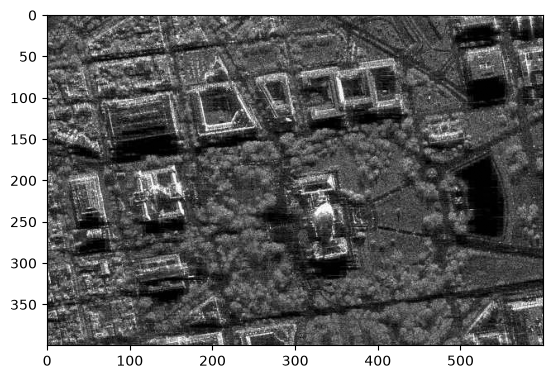

In [3]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')

# 2. Постройте гистограмму.

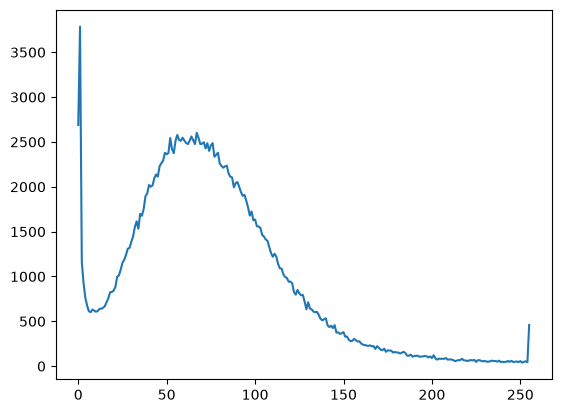

In [4]:
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(gray_hist)

# 3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

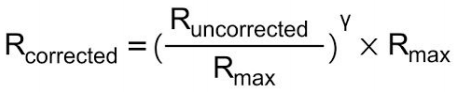

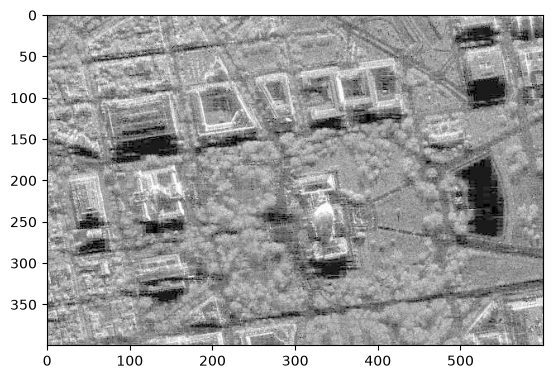

In [5]:
R_max = 255

gamma_1 = 0.4
image_1 = np.power(image_gray / R_max, gamma_1) * R_max
image_1 = np.uint8(image_1)

gamma_2 = 1.6
image_2 = np.power(image_gray / R_max, gamma_2) * R_max
image_2 = np.uint8(image_2)

plt.imshow(image_1, cmap='gray')

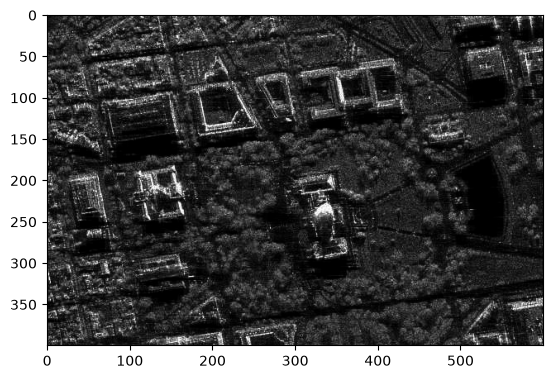

In [6]:
plt.imshow(image_2, cmap='gray')

# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

In [7]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim_1, diff_1) = structural_similarity(image_gray, image_1, full=True)
diff_1 = (diff_1 * 255).astype("uint8")
mse_1 = mean_squared_error(image_gray, image_1)
print("SSIM: {}".format(ssim_1))
print("MSE: {}".format(mse_1))

SSIM: 0.7121390473843303
MSE: 5517.938070833334


In [8]:
(ssim_2, diff_2) = structural_similarity(image_gray, image_2, full=True)
diff_2 = (diff_2 * 255).astype("uint8")
mse_2 = mean_squared_error(image_gray, image_2)
print("SSIM: {}".format(ssim_2))
print("MSE: {}".format(mse_2))

SSIM: 0.747893128472884
MSE: 1260.0477875


# 5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

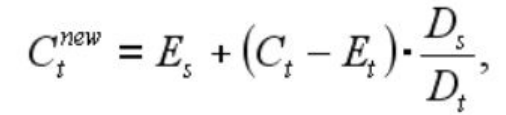

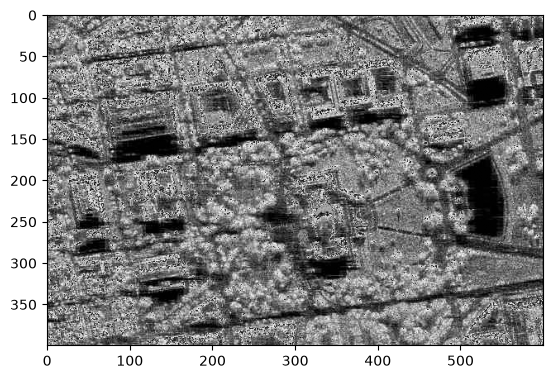

In [9]:
eq_gray = cv2.equalizeHist(image_gray)

E_eq = eq_gray.mean()  # E - среднее
D_eq = eq_gray.std()   # D - стандартное отклонение

E_im = image_gray.mean()
D_im = image_gray.std()

image_stat = E_eq + (image_gray - E_im) * (D_eq / D_im)
image_stat = np.uint8(image_stat)

plt.imshow(image_stat, cmap='gray')

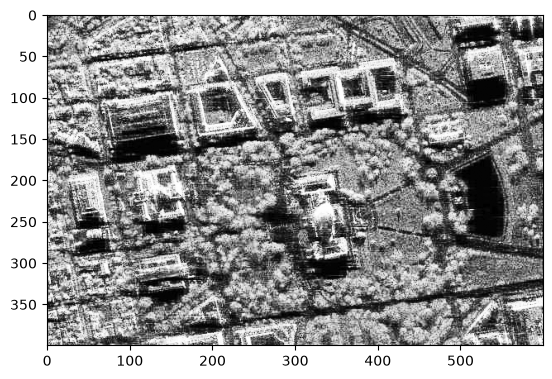

In [10]:
plt.imshow(eq_gray, cmap="gray") # для сравнения с эталоном

# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

3830


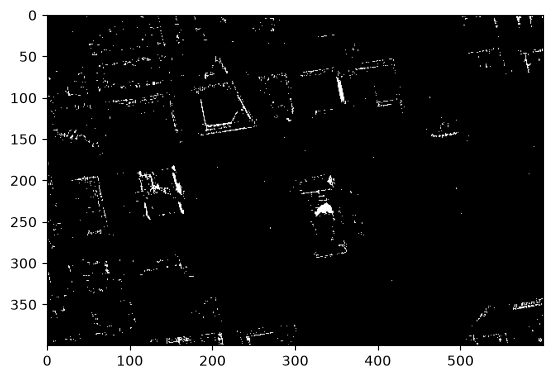

In [11]:
_,thresh1 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY)
print(thresh1[thresh1 == 255].size)
plt.imshow(thresh1, cmap='gray')

236170


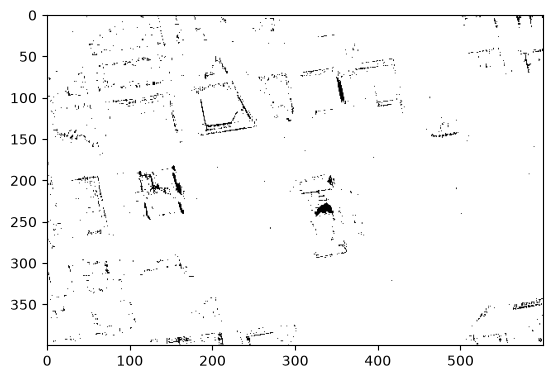

In [12]:
_,thresh2 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY_INV)
print(thresh2[thresh2 == 255].size)
plt.imshow(thresh2, cmap='gray')

0


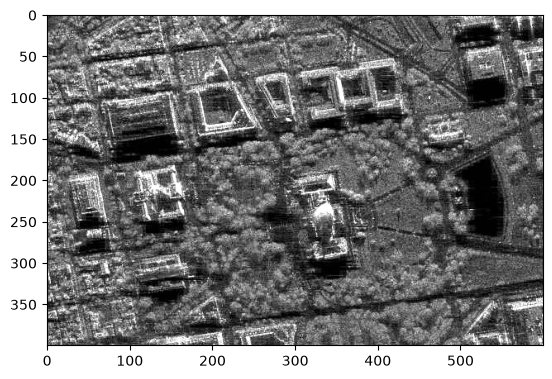

In [13]:
_,thresh3 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_TRUNC)
print(thresh3[thresh3 == 255].size)
plt.imshow(thresh3, cmap='gray')

460


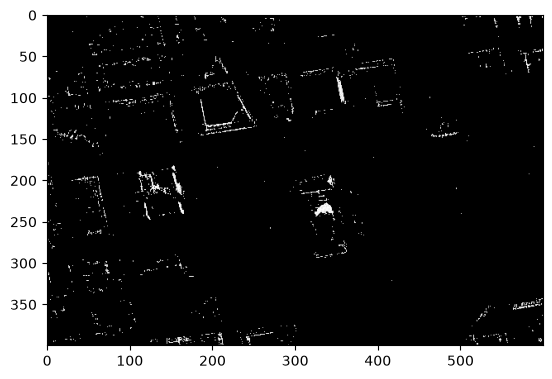

In [14]:
_,thresh4 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_TOZERO)
print(thresh4[thresh4 == 255].size)
plt.imshow(thresh4, cmap='gray')

0


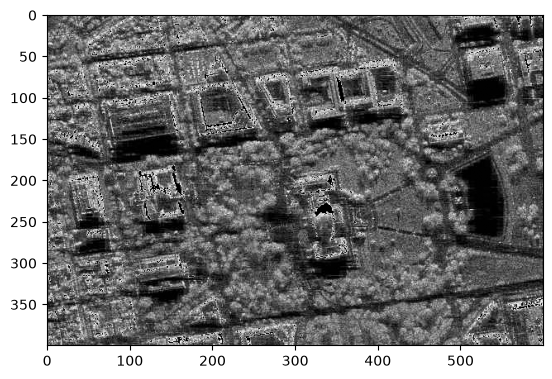

In [15]:
_,thresh5 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_TOZERO_INV)
print(thresh5[thresh5 == 255].size)
plt.imshow(thresh5, cmap='gray')